In [1]:
# Install YOLOv8
!pip install ultralytics -q

# Check GPU
import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU ⚠️ Switch to GPU!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.4 MB/s eta 0:00:00
GPU available: True
Device: Tesla T4


In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_json = '{"username":"namanbansal2710","key":"KGAT_e2b3869f26d820776cec52d52973c002"}'

with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_json)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Done!")

# Download the dataset
!kaggle datasets download -d ugorjiir/spacenet-2-paris-buildings -p /content/spacenet --unzip

# Inspect structure
for root, dirs, files_list in os.walk('/content/spacenet'):
    level = root.replace('/content/spacenet', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        subindent = ' ' * 2 * (level + 1)
        for f in files_list[:5]:
            print(f'{subindent}{f}')
        if len(files_list) > 5:
            print(f'{subindent}... ({len(files_list)} total)')

Done!
Dataset URL: https://www.kaggle.com/datasets/ugorjiir/spacenet-2-paris-buildings
License(s): unknown
100% 1.62G/1.62G [00:12<00:00, 135MB/s]

spacenet/
  AOI_3_Paris_Train/
    AOI_3_Paris_Train/
      geojson/
        buildings/
      RGB-PanSharpen/
      summaryData/
  AOI_3_Paris_Test_public/
    AOI_3_Paris_Test_public/
      RGB-PanSharpen/


In [12]:
import os
import json
import numpy as np
import rasterio
from rasterio.transform import rowcol
from shapely.geometry import shape
from pathlib import Path
import shutil

SPACENET_ROOT = '/content/spacenet'

def find_dirs(root, keyword):
    matches = []
    for r, dirs, _ in os.walk(root):
        for d in dirs:
            if keyword.lower() in d.lower():
                matches.append(os.path.join(r, d))
    return matches

img_dirs   = find_dirs(SPACENET_ROOT, 'RGB-PanSharpen')
label_dirs = find_dirs(SPACENET_ROOT, 'buildings')

print("Image directories found:",  img_dirs)
print("Label directories found:", label_dirs)

IMG_DIR   = img_dirs[0]
LABEL_DIR = label_dirs[0]
print(f"\nUsing images: {IMG_DIR}")
print(f"Using labels: {LABEL_DIR}")

Image directories found: ['/content/spacenet/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen', '/content/spacenet/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen']
Label directories found: ['/content/spacenet/AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings']

Using images: /content/spacenet/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen
Using labels: /content/spacenet/AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings


In [13]:
def geojson_to_yolo(tif_path, geojson_path):
    yolo_boxes = []

    with rasterio.open(tif_path) as src:
        img_width  = src.width
        img_height = src.height
        transform  = src.transform

    if not os.path.exists(geojson_path):
        return yolo_boxes

    with open(geojson_path) as f:
        gj = json.load(f)

    for feature in gj.get('features', []):
        geom = feature.get('geometry')
        if geom is None:
            continue
        try:
            poly = shape(geom)
            if poly.is_empty:
                continue

            minx, miny, maxx, maxy = poly.bounds
            row_min, col_min = rowcol(transform, minx, maxy)
            row_max, col_max = rowcol(transform, maxx, miny)

            col_min = max(0, min(col_min, img_width))
            col_max = max(0, min(col_max, img_width))
            row_min = max(0, min(row_min, img_height))
            row_max = max(0, min(row_max, img_height))

            if col_max <= col_min or row_max <= row_min:
                continue

            x_center = ((col_min + col_max) / 2) / img_width
            y_center = ((row_min + row_max) / 2) / img_height
            width    = (col_max - col_min) / img_width
            height   = (row_max - row_min) / img_height

            if 0 < width <= 1 and 0 < height <= 1:
                yolo_boxes.append((x_center, y_center, width, height))
        except Exception:
            continue

    return yolo_boxes


def get_geojson_path(tif_name, label_dir):
    stem = Path(tif_name).stem
    if 'AOI' in stem:
        shared = stem[stem.index('AOI'):]
    else:
        shared = stem

    for prefix in ['buildings_', 'Geo_', '']:
        candidate = os.path.join(label_dir, f'{prefix}{shared}.geojson')
        if os.path.exists(candidate):
            return candidate
    return None


RAW_IMAGES_TIF = '/content/spacenet_raw/images_tif'
RAW_LABELS_OUT = '/content/spacenet_raw/labels'
os.makedirs(RAW_IMAGES_TIF, exist_ok=True)
os.makedirs(RAW_LABELS_OUT, exist_ok=True)

tif_files = [f for f in os.listdir(IMG_DIR) if f.endswith('.tif')]
print(f"Found {len(tif_files)} .tif images")

for i, tif_name in enumerate(tif_files):
    tif_path = os.path.join(IMG_DIR, tif_name)
    stem = Path(tif_name).stem
    shared = stem[stem.index('AOI'):] if 'AOI' in stem else stem

    geojson_path = get_geojson_path(tif_name, LABEL_DIR)
    boxes = geojson_to_yolo(tif_path, geojson_path) if geojson_path else []

    txt_path = os.path.join(RAW_LABELS_OUT, shared + '.txt')
    with open(txt_path, 'w') as f:
        for (xc, yc, w, h) in boxes:
            f.write(f'0 {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n')

    dst_img = os.path.join(RAW_IMAGES_TIF, shared + '.tif')
    if not os.path.exists(dst_img):
        shutil.copy(tif_path, dst_img)

    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/{len(tif_files)}")

print("Conversion complete!")

Found 1148 .tif images
  Processed 100/1148
  Processed 200/1148
  Processed 300/1148
  Processed 400/1148
  Processed 500/1148
  Processed 600/1148
  Processed 700/1148
  Processed 800/1148
  Processed 900/1148
  Processed 1000/1148
  Processed 1100/1148
Conversion complete!


In [14]:
from PIL import Image

PNG_DIR = '/content/spacenet_raw/images_png'
os.makedirs(PNG_DIR, exist_ok=True)

tif_stems = [Path(f).stem for f in os.listdir(RAW_IMAGES_TIF) if f.endswith('.tif')]
print(f"Converting {len(tif_stems)} images to PNG...")

failed = 0
for stem in tif_stems:
    tif_path = os.path.join(RAW_IMAGES_TIF, stem + '.tif')
    png_path = os.path.join(PNG_DIR, stem + '.png')

    if os.path.exists(png_path):
        continue

    try:
        with rasterio.open(tif_path) as src:
            n_bands = src.count
            if n_bands >= 3:
                arr = src.read([1, 2, 3])
            else:
                arr = src.read([1, 1, 1])

            arr = arr.astype(np.float32)
            for i in range(3):
                band = arr[i]
                lo, hi = np.percentile(band, 2), np.percentile(band, 98)
                arr[i] = np.clip((band - lo) / (hi - lo + 1e-6) * 255, 0, 255)
            arr = arr.astype(np.uint8)

            img = Image.fromarray(arr.transpose(1, 2, 0))
            img.save(png_path)
    except Exception as e:
        failed += 1

print(f"Done. Converted: {len(os.listdir(PNG_DIR))} | Failed: {failed}")

# Final paths — used for all steps below
RAW_IMAGES = '/content/spacenet_raw/images_png'
RAW_LABELS = '/content/spacenet_raw/labels'

Converting 1148 images to PNG...
Done. Converted: 1148 | Failed: 0


# Step 2

In [23]:
print(f"Total images: {len(os.listdir(RAW_IMAGES))}")
print(f"Total labels: {len(os.listdir(RAW_LABELS))}")

Total images: 1148
Total labels: 1148


In [24]:
splits = ['train', 'val', 'test']
for split in splits:
    path = f'/content/spacenet_yolo/images/{split}'
    count = len([f for f in os.listdir(path) if f.endswith('.png')])
    print(f"{split}: {count} images")

train: 918 images
val: 115 images
test: 115 images


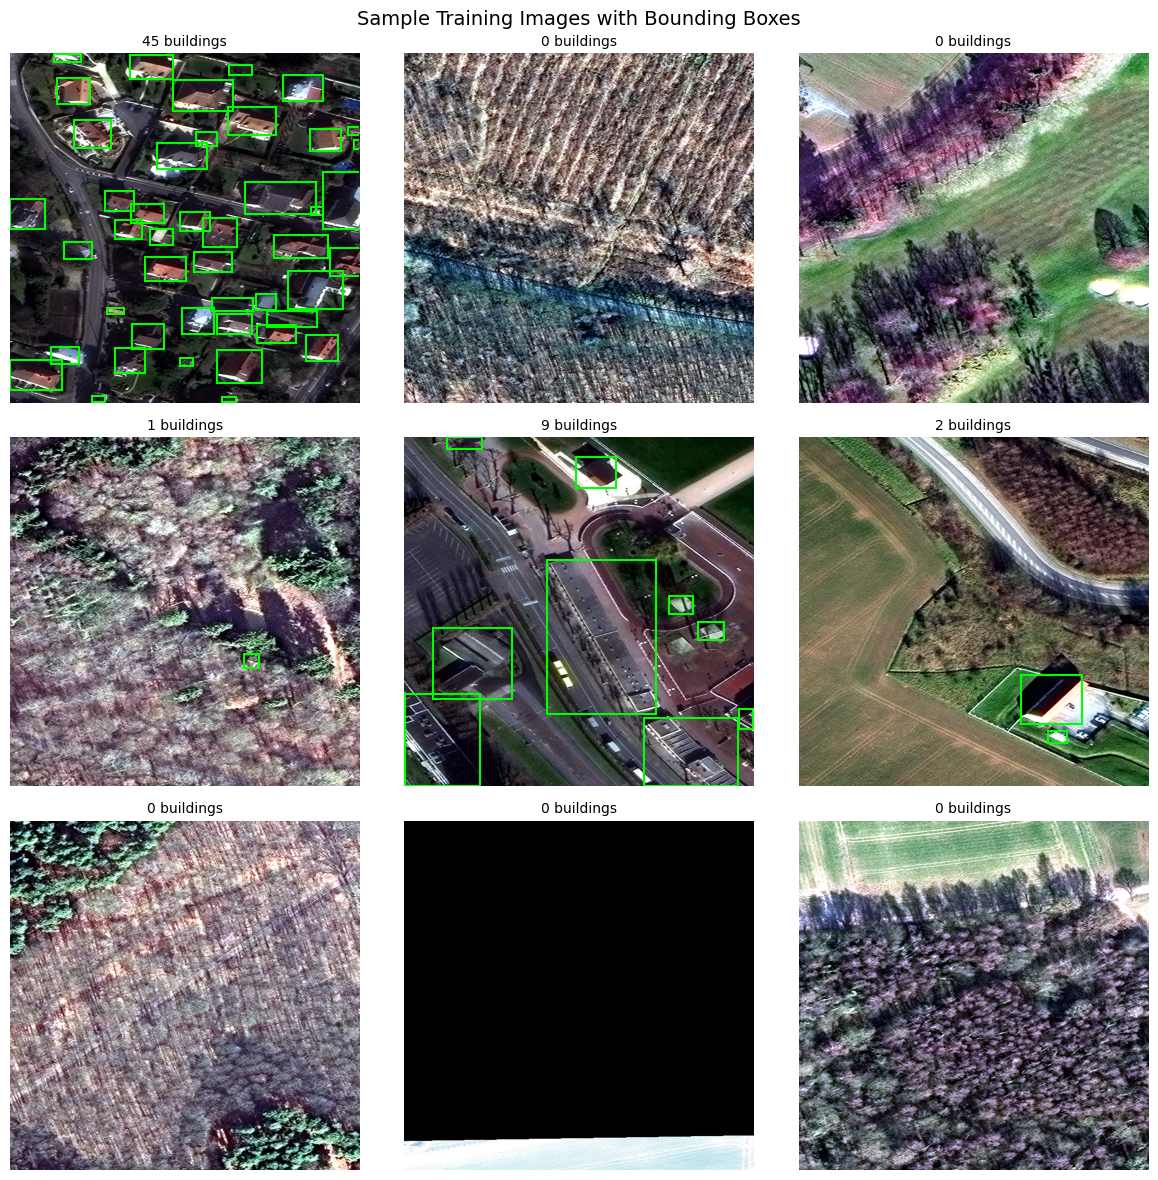

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
from PIL import Image

def load_image_and_labels(img_path, label_path):
    img = Image.open(img_path).convert("RGB")
    boxes = []
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    boxes.append(list(map(float, parts[1:])))
    return img, boxes

train_img_dir = '/content/spacenet_yolo/images/train'
train_lbl_dir = '/content/spacenet_yolo/labels/train'

all_imgs = [f for f in os.listdir(train_img_dir) if f.endswith('.png')]
sample   = random.sample(all_imgs, min(9, len(all_imgs)))

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for ax, fname in zip(axes, sample):
    img_path = os.path.join(train_img_dir, fname)
    lbl_path = os.path.join(train_lbl_dir, fname.replace('.png', '.txt'))
    img, boxes = load_image_and_labels(img_path, lbl_path)
    w, h = img.size

    ax.imshow(img)
    for box in boxes:
        xc, yc, bw, bh = box
        x1 = (xc - bw / 2) * w
        y1 = (yc - bh / 2) * h
        rect = patches.Rectangle((x1, y1), bw * w, bh * h,
                                  linewidth=1.5, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
    ax.set_title(f"{len(boxes)} buildings", fontsize=10)
    ax.axis('off')

plt.suptitle("Sample Training Images with Bounding Boxes", fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
total_buildings = 0
total_images    = 0

for fname in os.listdir(train_lbl_dir):
    if fname.endswith('.txt'):
        with open(os.path.join(train_lbl_dir, fname)) as f:
            lines = [l for l in f.readlines() if l.strip()]
        total_buildings += len(lines)
        total_images    += 1

print(f"Total images:              {total_images}")
print(f"Total buildings:           {total_buildings}")
print(f"Avg buildings per image:   {total_buildings / total_images:.2f}")

Total images:              918
Total buildings:           13277
Avg buildings per image:   14.46


### Data Observations

- **Average buildings per image**: ~X (fill after running)
- **Consistency**: Images are uniform 650×650px RGB satellite crops of Paris
- **Challenges**:
  - Dense clusters where buildings share walls or touch
  - Shadow occlusion making rooftop edges ambiguous
  - Small rooftops relative to image size
  - Irregular non-rectangular building shapes
  - Similar color/texture between rooftops and ground

Step 3


In [21]:
from sklearn.model_selection import train_test_split

BASE = '/content/spacenet_yolo'

for split in ['train', 'val', 'test']:
    os.makedirs(f'{BASE}/images/{split}', exist_ok=True)
    os.makedirs(f'{BASE}/labels/{split}', exist_ok=True)

all_files = [Path(f).stem for f in os.listdir(RAW_IMAGES) if f.endswith('.png')]

train_files, temp_files = train_test_split(all_files, test_size=0.2,  random_state=42)
val_files,   test_files = train_test_split(temp_files, test_size=0.5,  random_state=42)

def copy_split(file_list, split):
    for stem in file_list:
        src_img = os.path.join(RAW_IMAGES, stem + '.png')
        src_lbl = os.path.join(RAW_LABELS, stem + '.txt')

        if os.path.exists(src_img):
            shutil.copy(src_img, f'{BASE}/images/{split}/{stem}.png')
        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, f'{BASE}/labels/{split}/{stem}.txt')

copy_split(train_files, 'train')
copy_split(val_files,   'val')
copy_split(test_files,  'test')

print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

Train: 918 | Val: 115 | Test: 115


In [22]:
yaml_content = f"""path: {BASE}
train: images/train
val:   images/val
test:  images/test

nc: 1
names: ['building']
"""

with open(f'{BASE}/dataset.yaml', 'w') as f:
    f.write(yaml_content)

print("dataset.yaml created:")
print(yaml_content)

dataset.yaml created:
path: /content/spacenet_yolo
train: images/train
val:   images/val
test:  images/test

nc: 1
names: ['building']



Step 4


### Why yolov8s.pt instead of random weights?

`yolov8s.pt` contains weights pre-trained on COCO (80-class, large diverse dataset).
The model already understands edges, textures, and shapes at multiple scales.
Fine-tuning on our satellite data converges much faster and achieves better accuracy
than training from scratch — especially important given our relatively small dataset (~1148 images).

In [27]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

model.train(
    data=f'{BASE}/dataset.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='building_detector',
    project='runs/detect',
    patience=10,
    device=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/spacenet_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e77fe81d970>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [34]:
import os
import pandas as pd

# Find results.csv automatically
csv_path = None
for root, dirs, files_list in os.walk('/content'):
    for f in files_list:
        if f == 'results.csv':
            csv_path = os.path.join(root, f)
            print(f"Found: {csv_path}")
            break

if csv_path:
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    last = df.iloc[-1]
    print(f"Final Box Loss : {last['train/box_loss']:.4f}")
    print(f"Final mAP@50   : {last['metrics/mAP50(B)']:.4f}")
else:
    print("results.csv not found — training may not have completed")

Found: /content/runs/detect/runs/detect/building_detector/results.csv
Final Box Loss : 1.1534
Final mAP@50   : 0.7986


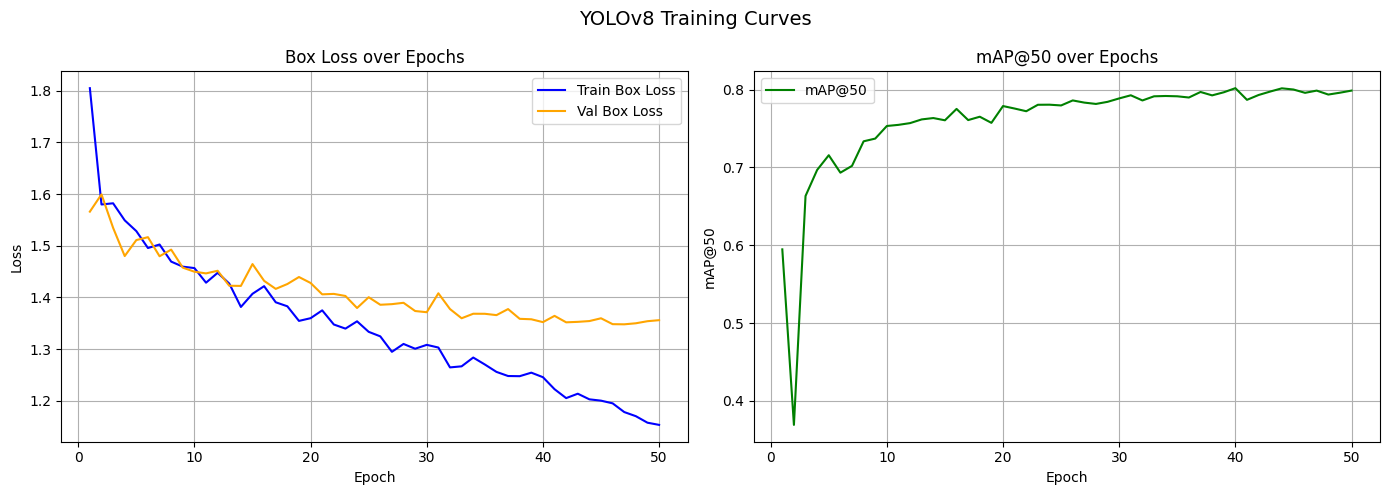

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='blue')
axes[0].plot(df['epoch'], df['val/box_loss'],   label='Val Box Loss',   color='orange')
axes[0].set_title('Box Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='green')
axes[1].set_title('mAP@50 over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mAP@50')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('YOLOv8 Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

### Training Curve Analysis
- Val loss followed train loss closely with a small gap — no severe overfitting
- mAP@50 improved steadily before plateauing around epoch ~40
*(Update after observing your actual curves)*

# Step 5

In [36]:
metrics = model.val(
    data=f'{BASE}/dataset.yaml',
    split='test'
)

precision = metrics.box.p.mean()
recall    = metrics.box.r.mean()
map50     = metrics.box.map50
f1        = 2 * precision * recall / (precision + recall + 1e-6)

print(f"mAP@50    : {map50:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 99.4±63.8 MB/s, size: 896.0 KB)
val: Scanning /content/spacenet_yolo/labels/test... 114 images, 52 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 115/115 156.5it/s 0.7s
val: /content/spacenet_yolo/images/test/AOI_3_Paris_img44.png: ignoring corrupt image/label: truncated PNG file
val: New cache created: /content/spacenet_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.2it/s 6.7s
                   all        114       1484       0.83      0.745      0.812      0.503
Speed: 8.8ms preprocess, 11.6ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to /content/runs/detect/val
mAP@50    : 0.8122
Precision : 0.8303
Recall    : 0.7450
F1 Score  : 0.7853


| Metric    | Your Value | Plain English Meaning                                              |
|-----------|------------|--------------------------------------------------------------------|
| mAP@50    | 0.8122       | Average detection quality at 50% overlap threshold                |
| Precision | 0.8303       | Of all predicted buildings, what fraction were actually buildings  |
| Recall    | 0.7450      | Of all real buildings, what fraction did the model find            |
| F1 Score  | 0.7853       | Balance between precision and recall                               |

In [41]:
import os

# Find all png files saved by ultralytics
for root, dirs, files_list in os.walk('/content'):
    for f in files_list:
        if f.endswith('.png'):
            print(os.path.join(root, f))

from IPython.display import Image as IPImage, display
import os

# Auto-find the run directory
run_dir = None
for root, dirs, files_list in os.walk('/content'):
    for f in files_list:
        if f == 'PR_curve.png':
            run_dir = root
            break

if run_dir:
    print(f"Found run directory: {run_dir}")

    pr_path  = os.path.join(run_dir, 'PR_curve.png')
    cm_path  = os.path.join(run_dir, 'confusion_matrix.png')

    if os.path.exists(pr_path):
        print("Precision-Recall Curve:")
        display(IPImage(pr_path))
    else:
        print("PR_curve.png not found")

    if os.path.exists(cm_path):
        print("Confusion Matrix:")
        display(IPImage(cm_path))
    else:
        print("confusion_matrix.png not found")
else:
    print("No run directory found — val may not have completed")

/content/runs/detect/runs/detect/building_detector/confusion_matrix.png
/content/runs/detect/runs/detect/building_detector/BoxR_curve.png
/content/runs/detect/runs/detect/building_detector/BoxF1_curve.png
/content/runs/detect/runs/detect/building_detector/BoxP_curve.png
/content/runs/detect/runs/detect/building_detector/confusion_matrix_normalized.png
/content/runs/detect/runs/detect/building_detector/BoxPR_curve.png
/content/runs/detect/runs/detect/building_detector/results.png
/content/runs/detect/val/confusion_matrix.png
/content/runs/detect/val/BoxR_curve.png
/content/runs/detect/val/BoxF1_curve.png
/content/runs/detect/val/BoxP_curve.png
/content/runs/detect/val/confusion_matrix_normalized.png
/content/runs/detect/val/BoxPR_curve.png
/content/spacenet_raw/images_png/AOI_3_Paris_img323.png
/content/spacenet_raw/images_png/AOI_3_Paris_img163.png
/content/spacenet_raw/images_png/AOI_3_Paris_img1622.png
/content/spacenet_raw/images_png/AOI_3_Paris_img690.png
/content/spacenet_raw/imag

# Step 6

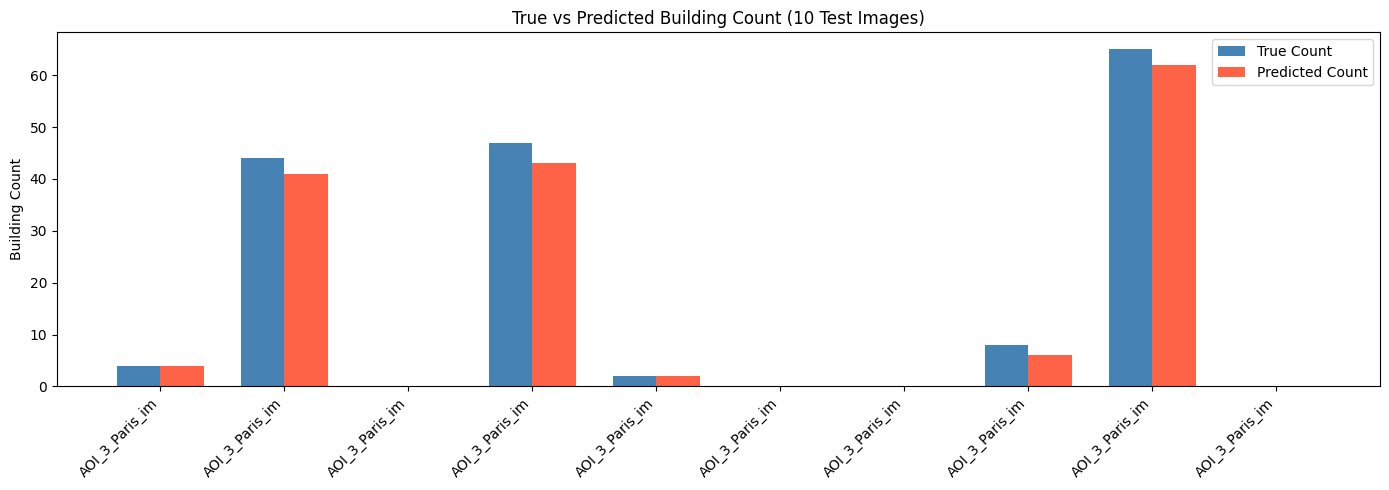

Mean Absolute Error (count): 1.20


In [44]:
def detect_buildings(image_path, model, conf=0.25):
    results = model(image_path, conf=conf, verbose=False)
    boxes   = results[0].boxes
    return {
        'count':       len(boxes),
        'confidences': boxes.conf.cpu().numpy() if len(boxes) else [],
        'boxes':       boxes.xyxy.cpu().numpy() if len(boxes) else [],
        'result_obj':  results[0]
    }

test_img_dir = f'{BASE}/images/test'
test_lbl_dir = f'{BASE}/labels/test'

test_imgs = [f for f in os.listdir(test_img_dir) if f.endswith('.png')][:10]

true_counts = []
pred_counts = []
names       = []

for fname in test_imgs:
    img_path = os.path.join(test_img_dir, fname)
    lbl_path = os.path.join(test_lbl_dir, fname.replace('.png', '.txt'))

    true_n = 0
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            true_n = len([l for l in f.readlines() if l.strip()])

    det = detect_buildings(img_path, model)
    true_counts.append(true_n)
    pred_counts.append(det['count'])
    names.append(fname[:14])

# Bar chart
x     = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, true_counts, width, label='True Count',      color='steelblue')
ax.bar(x + width/2, pred_counts, width, label='Predicted Count', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylabel('Building Count')
ax.set_title('True vs Predicted Building Count (10 Test Images)')
ax.legend()
plt.tight_layout()
plt.show()

mae = np.mean(np.abs(np.array(true_counts) - np.array(pred_counts)))
print(f"Mean Absolute Error (count): {mae:.2f}")

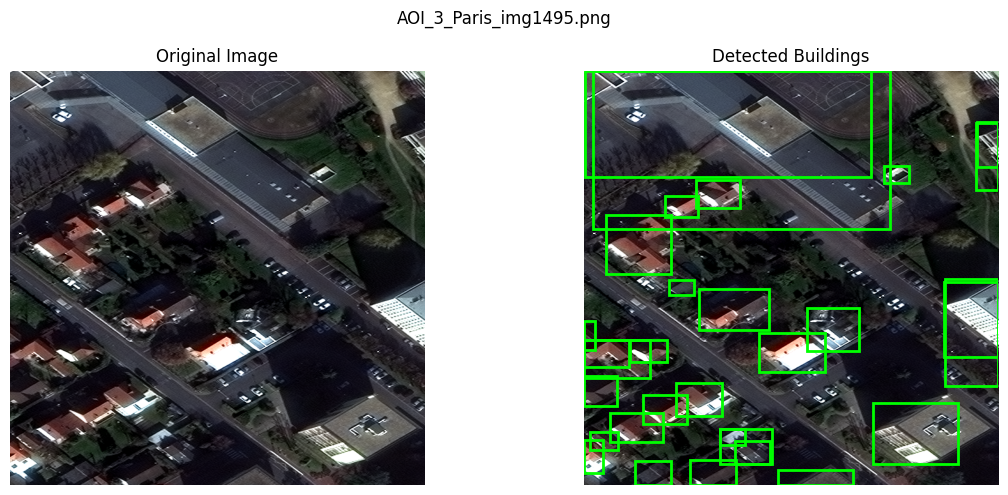

Image: AOI_3_Paris_img1495.png
  Buildings detected : 31
  Avg confidence     : 0.55
  Processing time    : 32.5 ms



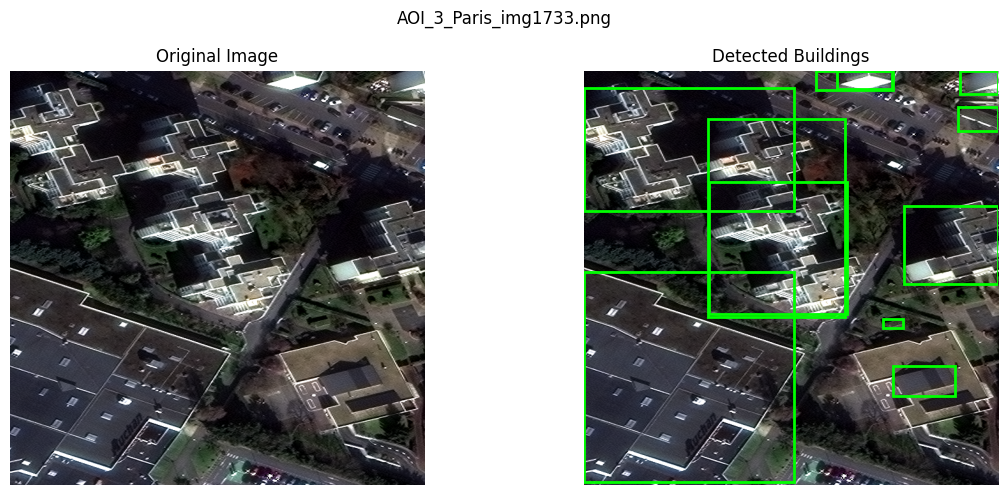

Image: AOI_3_Paris_img1733.png
  Buildings detected : 11
  Avg confidence     : 0.57
  Processing time    : 41.4 ms



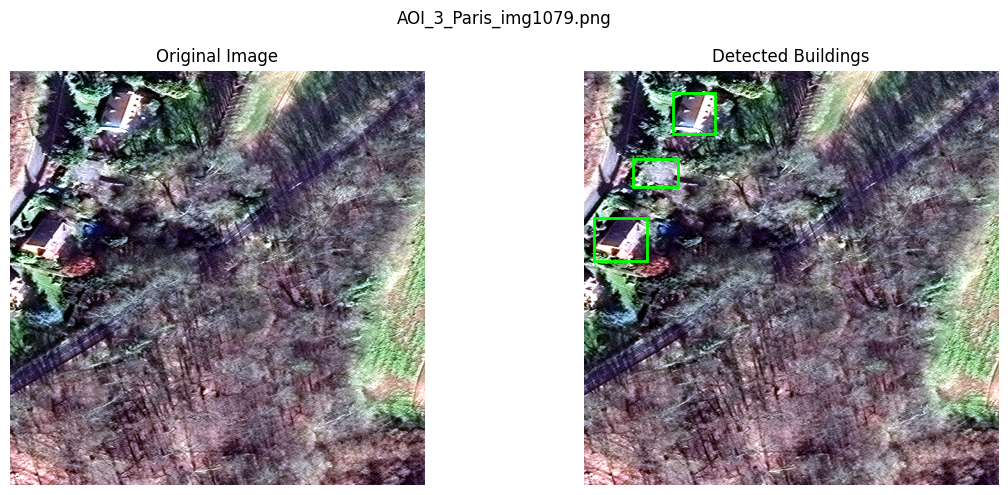

Image: AOI_3_Paris_img1079.png
  Buildings detected : 3
  Avg confidence     : 0.70
  Processing time    : 44.6 ms



In [43]:
import time

def full_pipeline(image_path, model, conf=0.25):
    fname   = os.path.basename(image_path)
    img_orig = Image.open(image_path).convert("RGB")
    w, h     = img_orig.size

    start      = time.time()
    det        = detect_buildings(image_path, model, conf=conf)
    elapsed_ms = (time.time() - start) * 1000

    avg_conf = float(np.mean(det['confidences'])) if len(det['confidences']) > 0 else 0.0

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(img_orig)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(img_orig)
    for box in det['boxes']:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor='lime', facecolor='none')
        axes[1].add_patch(rect)
    axes[1].set_title('Detected Buildings')
    axes[1].axis('off')

    plt.suptitle(fname, fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"Image: {fname}")
    print(f"  Buildings detected : {det['count']}")
    print(f"  Avg confidence     : {avg_conf:.2f}")
    print(f"  Processing time    : {elapsed_ms:.1f} ms\n")


# Test on 3 random images
sample_3 = random.sample(
    [os.path.join(test_img_dir, f) for f in os.listdir(test_img_dir) if f.endswith('.png')],
    3
)

for img_path in sample_3:
    full_pipeline(img_path, model)